# KNN Loan Applicant Credit Risk Analysis
## Part-1: Data Exploration and Pre-processing
## Part-2: Model Building with KNN

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [3]:
cd C:\Users\rjban\Desktop\ml\ML Projects

C:\Users\rjban\Desktop\ml\ML Projects


In [4]:
df = pd.read_excel(r"1768299714153-ML Project - KNN Loan Applicant Credit Risk Analysis U 16955473070.xlsx")

In [5]:
df.head()

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
0,40.50,2,6,0.842666,594,0,0
1,41.25,5,2,0.791667,754,0,0
2,39.50,5,2,0.727273,779,0,0
3,35.00,1,4,0.820232,818,0,0
4,34.00,3,3,0.455581,853,0,1


In [6]:
df.isnull().sum()

Age                           0
Total Work Experience         0
Number of years in city       0
Cost to Request Ratio         0
Cibil score                   0
Overdrafts past12months       0
Total bounces past12months    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         8995 non-null   float64
 1   Total Work Experience       8995 non-null   int64  
 2   Number of years in city     8995 non-null   int64  
 3   Cost to Request Ratio       8995 non-null   float64
 4   Cibil score                 8995 non-null   int64  
 5   Overdrafts past12months     8995 non-null   int64  
 6   Total bounces past12months  8995 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 492.0 KB


In [8]:
df.describe()

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
count,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000
mean,38.808202,2.131073,4.288160,0.831183,752.626570,0.322068,1.162757
std,10.203371,0.892141,1.269416,0.490216,67.645792,0.914998,2.352798
min,18.100000,1.000000,1.000000,0.008466,351.000000,0.000000,0.000000
25%,30.830000,1.000000,3.000000,0.662147,730.000000,0.000000,0.000000
50%,37.200000,2.000000,4.000000,0.800000,768.000000,0.000000,0.000000
75%,45.400000,3.000000,5.000000,0.930908,797.000000,0.000000,1.000000
max,83.800000,5.000000,6.000000,12.006623,882.000000,12.000000,12.000000


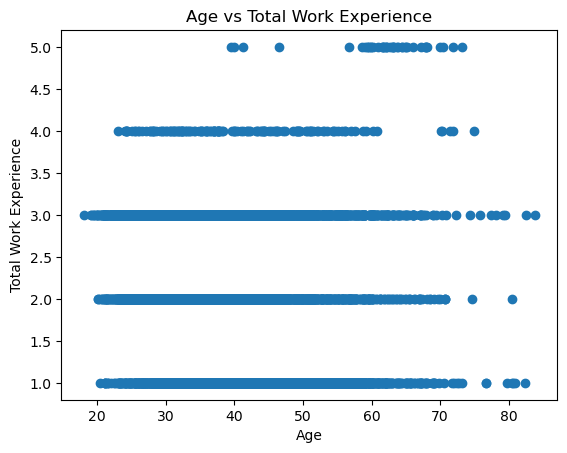

In [9]:
plt.figure()
plt.scatter(df["Age"], df["Total Work Experience"])
plt.xlabel("Age")
plt.ylabel("Total Work Experience")
plt.title("Age vs Total Work Experience")
plt.show()

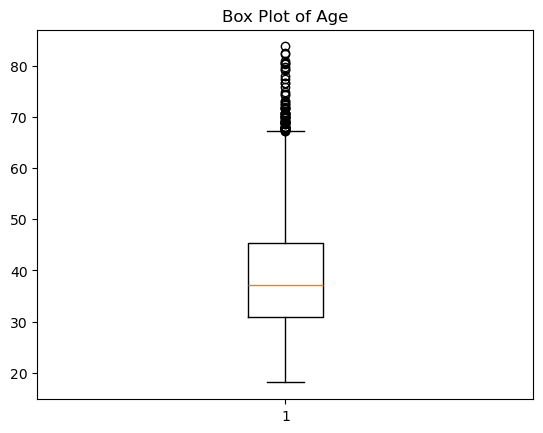

In [10]:
plt.figure()
plt.boxplot(df["Age"])
plt.title("Box Plot of Age")
plt.show()

In [15]:
df.head(2)

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
0,40.50,2,6,0.842666,594,0,0
1,41.25,5,2,0.791667,754,0,0


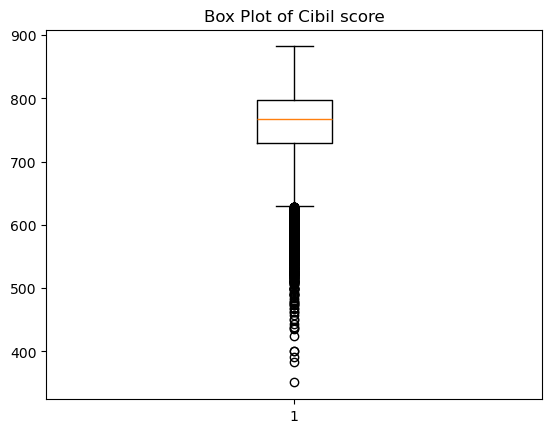

In [16]:
plt.figure()
plt.boxplot(df["Cibil score"])
plt.title("Box Plot of Cibil score")
plt.show()

In [17]:
df.head(2)

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
0,40.50,2,6,0.842666,594,0,0
1,41.25,5,2,0.791667,754,0,0


In [18]:
x = df.drop("Total bounces past12months", axis=1)
y = df["Total bounces past12months"]

In [20]:
x = pd.get_dummies(x, drop_first=True)

In [21]:
x.head()

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months
0,40.50,2,6,0.842666,594,0
1,41.25,5,2,0.791667,754,0
2,39.50,5,2,0.727273,779,0
3,35.00,1,4,0.820232,818,0
4,34.00,3,3,0.455581,853,0


In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

In [23]:
knn = KNeighborsClassifier(n_neighbors=5)

In [24]:
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [26]:
knn.score(x_train, y_train)

0.6797966963151207

In [27]:
knn.score(x_test, y_test)

0.6350500185253798

In [29]:
yp = knn.predict(x_test)

In [31]:
print("Accuracy Score:", accuracy_score(y_test, yp))

Accuracy Score: 0.6350500185253798


In [32]:
train_scores = []
test_scores = []

In [33]:
for k in range(1, 15):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    
    train_scores.append(model.score(x_train, y_train))
    test_scores.append(model.score(x_test, y_test))

In [34]:
for k in range(1, 15):
    print(f"K={k} | Train Score={train_scores[k-1]:.4f} | Test Score={test_scores[k-1]:.4f}")

K=1 | Train Score=1.0000 | Test Score=0.5320
K=2 | Train Score=0.7395 | Test Score=0.6180
K=3 | Train Score=0.7052 | Test Score=0.6202
K=4 | Train Score=0.6890 | Test Score=0.6199
K=5 | Train Score=0.6798 | Test Score=0.6351
K=6 | Train Score=0.6709 | Test Score=0.6432
K=7 | Train Score=0.6657 | Test Score=0.6443
K=8 | Train Score=0.6618 | Test Score=0.6451
K=9 | Train Score=0.6584 | Test Score=0.6462
K=10 | Train Score=0.6574 | Test Score=0.6484
K=11 | Train Score=0.6568 | Test Score=0.6480
K=12 | Train Score=0.6560 | Test Score=0.6528
K=13 | Train Score=0.6550 | Test Score=0.6521
K=14 | Train Score=0.6549 | Test Score=0.6521


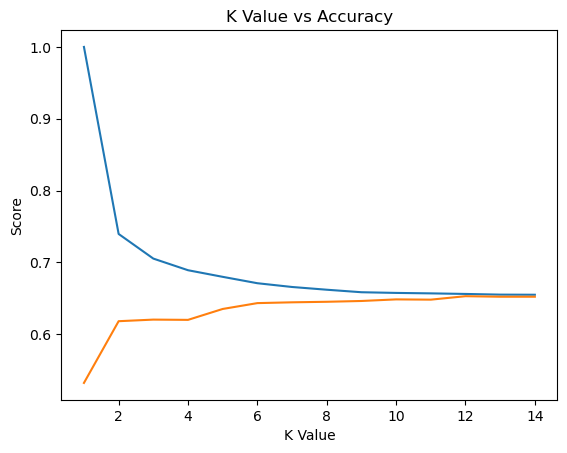

In [38]:
plt.figure()
plt.plot(range(1,15), train_scores)
plt.plot(range(1,15), test_scores)
plt.xlabel("K Value")
plt.ylabel("Score")
plt.title("K Value vs Accuracy")
plt.show()